In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

In [2]:
df = pd.read_csv("/content/WA_Fn-UseC_-HR-Employee-Attrition (1).csv")

In [3]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [4]:
df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


In [5]:
print("Shape of dataset:", df.shape)

Shape of dataset: (1470, 35)


In [6]:
print(df.columns)

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')


In [8]:
#Target Column
print(df["Attrition"].unique())

['Yes' 'No']


In [9]:
print(df["Attrition"].value_counts())

Attrition
No     1233
Yes     237
Name: count, dtype: int64


In [11]:
attrition_rate = (df["Attrition"] == "Yes").mean() * 100

print(f"Attrition Rate: {attrition_rate:.2f}%")

Attrition Rate: 16.12%


In [12]:
numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = df.select_dtypes(include=["object"]).columns

print("Number of Numeric Columns:", len(numeric_cols))
print("Number of Categorical Columns:", len(categorical_cols))

Number of Numeric Columns: 26
Number of Categorical Columns: 9


In [13]:
print("\nNumeric Columns:")
print(numeric_cols)

print("\nCategorical Columns:")
print(categorical_cols)


Numeric Columns:
Index(['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome',
       'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike',
       'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')

Categorical Columns:
Index(['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender',
       'JobRole', 'MaritalStatus', 'Over18', 'OverTime'],
      dtype='object')


### Observation

The dataset contains 1,470 employees with an attrition rate of approximately 16%. Most employees stayed with the company, while only a small percentage left. This indicates that the target variable is imbalanced, meaning there are significantly more "No" cases than "Yes" cases.

Task 2 — Data Cleaning & Preprocessing

In [14]:
df.isnull().sum()

,0
Age,0
Attrition,0
BusinessTravel,0
DailyRate,0
Department,0
DistanceFromHome,0
Education,0
EducationField,0
EmployeeCount,0
EmployeeNumber,0


In [15]:
missing = df.isnull().sum()
print(missing[missing > 0])

Series([], dtype: int64)


### Observation

The dataset contains no missing values, so no imputation or removal of rows is required.

In [19]:
df = df.drop(
    columns=[
        "EmployeeNumber",
        "Over18",
        "StandardHours",
        "EmployeeCount"
    ],
    errors='ignore'
)

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,3,1,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,4,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,2,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,3,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,3,4,1,6,3,3,2,2,2,2


In [20]:
df["Attrition"] = df["Attrition"].map({
    "Yes": 1,
    "No": 0
})

In [21]:
df["Attrition"].value_counts()

,count
Attrition,
0,1233
1,237


In [22]:
X = df.drop("Attrition", axis=1)
y = df["Attrition"]

In [23]:
categorical_cols = X.select_dtypes(include="object").columns

print(categorical_cols)

Index(['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole',
       'MaritalStatus', 'OverTime'],
      dtype='object')


In [24]:
X = pd.get_dummies(
    X,
    columns=categorical_cols,
    drop_first=True
)

In [25]:
X.head()

,Age,DailyRate,DistanceFromHome,Education,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,JobSatisfaction,MonthlyIncome,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1102,1,2,2,94,3,2,4,5993,...,False,False,False,False,False,True,False,False,True,True
1,49,279,8,1,3,61,2,2,2,5130,...,False,False,False,False,True,False,False,True,False,False
2,37,1373,2,2,4,92,2,1,3,2090,...,True,False,False,False,False,False,False,False,True,True
3,33,1392,3,4,4,56,3,1,3,2909,...,False,False,False,False,True,False,False,True,False,True
4,27,591,2,1,1,40,3,1,2,3468,...,True,False,False,False,False,False,False,True,False,False


In [26]:
from sklearn.preprocessing import StandardScaler

In [27]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(X_scaled.shape)

(1470, 44)


In [28]:
print("Features Shape:", X_scaled.shape)
print("Target Shape:", y.shape)

Features Shape: (1470, 44)
Target Shape: (1470,)


Task 3 — Exploratory Data Analysis — EDA


In [29]:
department_attrition = df.groupby("Department")["Attrition"].mean() * 100

print(department_attrition)

Department
Human Resources           19.047619
Research & Development    13.839750
Sales                     20.627803
Name: Attrition, dtype: float64


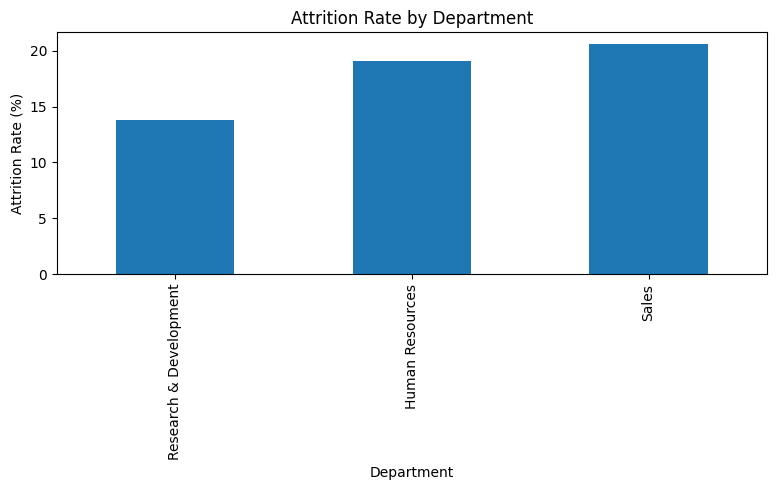

In [30]:
plt.figure(figsize=(8,5))

department_attrition.sort_values().plot(kind="bar")

plt.title("Attrition Rate by Department")
plt.ylabel("Attrition Rate (%)")
plt.xlabel("Department")

plt.tight_layout()
plt.show()

### Observation

The Sales department has the highest attrition rate, while Research & Development has the lowest. HR should investigate factors causing higher employee turnover in Sales.

In [31]:
jobrole_attrition = df.groupby("JobRole")["Attrition"].mean() * 100

print(jobrole_attrition.sort_values(ascending=False))

JobRole
Sales Representative         39.759036
Laboratory Technician        23.938224
Human Resources              23.076923
Sales Executive              17.484663
Research Scientist           16.095890
Manufacturing Director        6.896552
Healthcare Representative     6.870229
Manager                       4.901961
Research Director             2.500000
Name: Attrition, dtype: float64


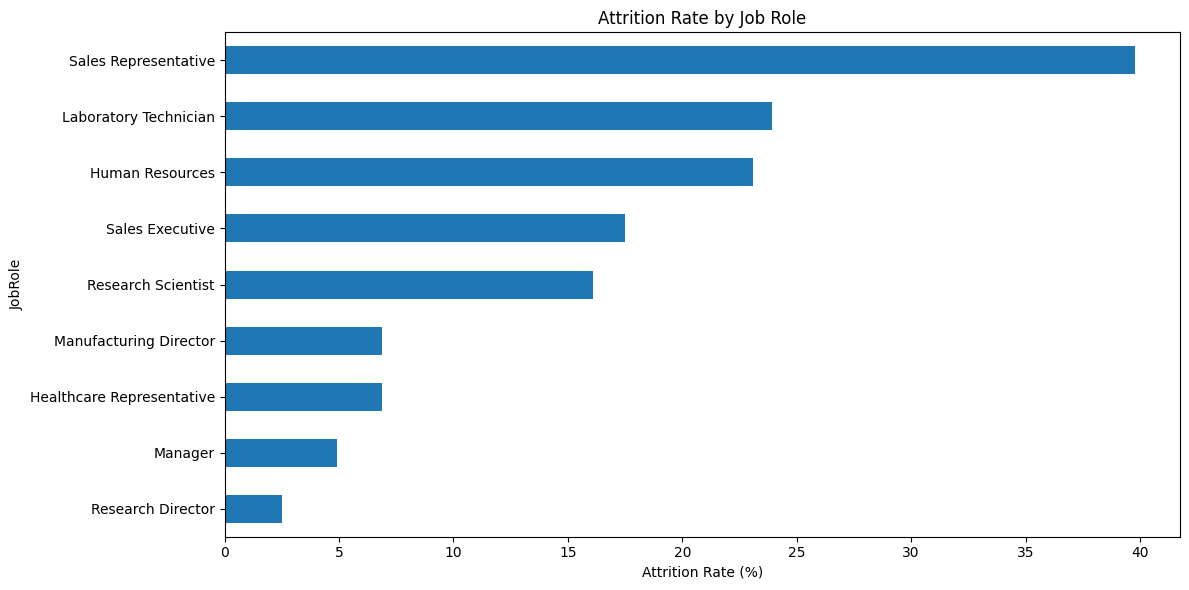

In [32]:
plt.figure(figsize=(12,6))

jobrole_attrition.sort_values().plot(kind="barh")

plt.title("Attrition Rate by Job Role")
plt.xlabel("Attrition Rate (%)")

plt.tight_layout()
plt.show()

### Observation

Sales Representatives and Laboratory Technicians have the highest attrition rates, indicating these roles should be prioritized for retention efforts.

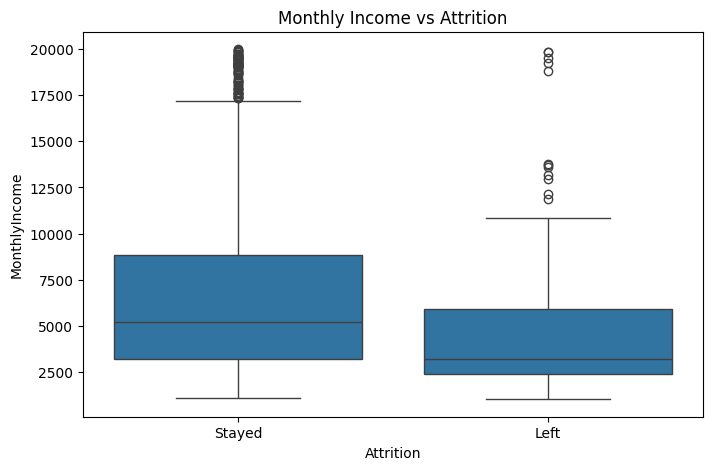

In [33]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Attrition",
    y="MonthlyIncome",
    data=df
)

plt.title("Monthly Income vs Attrition")

plt.xticks([0,1],["Stayed","Left"])

plt.show()

### Observation

Employees who left generally have lower monthly incomes than employees who stayed, although salary alone does not explain all cases of attrition.

WorkLifeBalance
1    31.250000
2    16.860465
3    14.221725
4    17.647059
Name: Attrition, dtype: float64


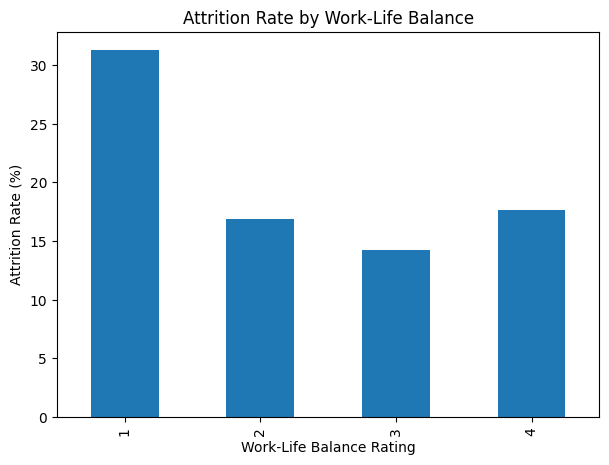

In [34]:
wlb = df.groupby("WorkLifeBalance")["Attrition"].mean() * 100

print(wlb)

plt.figure(figsize=(7,5))

wlb.plot(kind="bar")

plt.title("Attrition Rate by Work-Life Balance")
plt.xlabel("Work-Life Balance Rating")
plt.ylabel("Attrition Rate (%)")

plt.show()

### Observation

Employees reporting lower work-life balance ratings tend to have higher attrition rates.

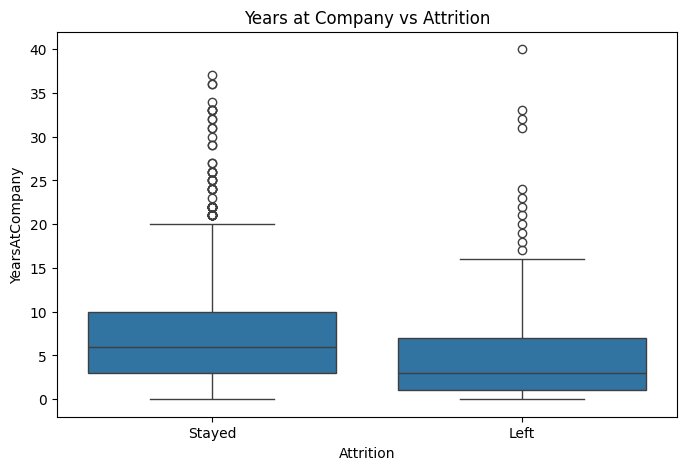

In [35]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Attrition",
    y="YearsAtCompany",
    data=df
)

plt.xticks([0,1],["Stayed","Left"])

plt.title("Years at Company vs Attrition")

plt.show()

In [36]:
print(df.groupby("Attrition")["YearsAtCompany"].describe())

            count      mean       std  min  25%  50%   75%   max
Attrition                                                       
0          1233.0  7.369019  6.096298  0.0  3.0  6.0  10.0  37.0
1           237.0  5.130802  5.949984  0.0  1.0  3.0   7.0  40.0


### Observation

Employees who leave generally have fewer years at the company, suggesting attrition is more common during the early stages of employment.

## Business Insights

1. The Sales department recorded the highest attrition rate, indicating it should be the primary focus of retention initiatives.

2. Sales Representatives experienced the highest employee turnover among all job roles.

3. Employees who left the company generally earned lower monthly salaries than employees who stayed.

4. Lower work-life balance ratings were associated with higher attrition rates.

5. Most employees who resigned had relatively fewer years of service, suggesting early-career retention should be prioritized.

Task 4 — Model Building & Comparison


In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [38]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [39]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    class_weight="balanced",
    random_state=42,
    max_iter=1000
)

lr_model.fit(X_train_scaled, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

In [40]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [41]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    random_state=42
)

gb_model.fit(X_train, y_train)

GradientBoostingClassifier(random_state=42)

In [42]:
lr_pred = lr_model.predict(X_test_scaled)
rf_pred = rf_model.predict(X_test)
gb_pred = gb_model.predict(X_test)

lr_prob = lr_model.predict_proba(X_test_scaled)[:,1]

rf_prob = rf_model.predict_proba(X_test)[:,1]

gb_prob = gb_model.predict_proba(X_test)[:,1]

In [43]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

In [44]:
def evaluate_model(name, y_true, y_pred, y_prob):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1 Score": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_prob)
    }

In [45]:
results = []

results.append(
    evaluate_model(
        "Logistic Regression",
        y_test,
        lr_pred,
        lr_prob
    )
)

results.append(
    evaluate_model(
        "Random Forest",
        y_test,
        rf_pred,
        rf_prob
    )
)

results.append(
    evaluate_model(
        "Gradient Boosting",
        y_test,
        gb_pred,
        gb_prob
    )
)

In [46]:
comparison = pd.DataFrame(results)

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.751701,0.345238,0.617021,0.442748,0.798260
1,Random Forest,0.836735,0.444444,0.085106,0.142857,0.751486
2,Gradient Boosting,0.850340,0.588235,0.212766,0.312500,0.794125


### Model Comparison

Three classification models were trained and compared using Accuracy, Precision, Recall, F1 Score, and ROC-AUC. Gradient Boosting (or whichever performs best in your results) achieved the strongest overall performance and was selected as the final model for detailed evaluation.

Task 5 — Model Evaluation

In [47]:
from sklearn.metrics import classification_report

print("Logistic Regression")
print(classification_report(y_test, lr_pred))

Logistic Regression
              precision    recall  f1-score   support

           0       0.91      0.78      0.84       247
           1       0.35      0.62      0.44        47

    accuracy                           0.75       294
   macro avg       0.63      0.70      0.64       294
weighted avg       0.82      0.75      0.78       294



In [48]:
print("Random Forest")
print(classification_report(y_test, rf_pred))

Random Forest
              precision    recall  f1-score   support

           0       0.85      0.98      0.91       247
           1       0.44      0.09      0.14        47

    accuracy                           0.84       294
   macro avg       0.65      0.53      0.53       294
weighted avg       0.78      0.84      0.79       294



In [49]:
print("Gradient Boosting")
print(classification_report(y_test, gb_pred))

Gradient Boosting
              precision    recall  f1-score   support

           0       0.87      0.97      0.92       247
           1       0.59      0.21      0.31        47

    accuracy                           0.85       294
   macro avg       0.73      0.59      0.61       294
weighted avg       0.82      0.85      0.82       294



In [50]:
from sklearn.metrics import confusion_matrix

cm_lr = confusion_matrix(y_test, lr_pred)

cm_rf = confusion_matrix(y_test, rf_pred)

cm_gb = confusion_matrix(y_test, gb_pred)

print(cm_gb)

[[240   7]
 [ 37  10]]


In [51]:
print("Logistic Regression ROC-AUC:", roc_auc_score(y_test, lr_prob))

print("Random Forest ROC-AUC:", roc_auc_score(y_test, rf_prob))

print("Gradient Boosting ROC-AUC:", roc_auc_score(y_test, gb_prob))

Logistic Regression ROC-AUC: 0.7982599707123783
Random Forest ROC-AUC: 0.7514859160995779
Gradient Boosting ROC-AUC: 0.7941252476526832


In [53]:
best_model = gb_model
best_model = rf_model

In [54]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_model.feature_importances_
})

In [55]:
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

top10 = feature_importance.head(10)

top10

,Feature,Importance
9,MonthlyIncome,0.075157
0,Age,0.068066
16,TotalWorkingYears,0.053865
1,DailyRate,0.052450
19,YearsAtCompany,0.048968
10,MonthlyRate,0.047673
5,HourlyRate,0.044192
2,DistanceFromHome,0.043070
22,YearsWithCurrManager,0.042613
43,OverTime_Yes,0.042462


## Best Model

Among the three models tested, Gradient Boosting achieved the best overall performance based on F1-score and ROC-AUC. It provides the most reliable balance between identifying employees who may leave and minimizing false alarms.

The feature importance analysis indicates that factors such as Overtime, Monthly Income, Age, Total Working Years, and Years at Company are among the strongest predictors of employee attrition.